# Part 4b: LOB Features — Engineering Signals & Measuring Predictive Power

---

Part 4a showed what the data looks like. This notebook builds the features and asks the first real question: *do they actually predict future returns?*

We work through four features in order of complexity — OFI, then a full resampled feature matrix — and measure the predictive power of each using the **Information Coefficient (IC)**: the Spearman rank correlation between a feature value now and the mid-price return at a future horizon. IC is a fast, model-free diagnostic. It does not require fitting a model; it just asks whether there is a monotone relationship between the feature and the next return, on average.

The notebook ends by explaining the distinction between IC and out-of-sample R² — the two are related but answer different questions — which sets up the model evaluation in Part 4c.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

LOB_DIR = 'data/lob'
ACTION_LABELS = {'A': 'Add order', 'C': 'Cancel order', 'T': 'Trade', 'F': 'Fill (partial)'}
SIDE_LABELS   = {'B': 'Bid (buy)', 'A': 'Ask (sell)', 'N': 'None (trade)'}

# Load NVDA calm period (used throughout this notebook)
nvda = pd.read_parquet(f'{LOB_DIR}/lob_mbp1_NVDA_calm_oct2023.parquet')
nvda.index = nvda.index.tz_convert('US/Eastern')

## Order Flow Imbalance (OFI)

OBI measures the *static* state of the book at a given moment. Order Flow Imbalance (OFI), introduced by Cont, Kukanov, and Stoikov (2014), measures the *dynamic* change in the book — how the queue is evolving from one event to the next.

At each event, the best bid queue changes: an add event increases it, a cancel or trade decreases it. Same for the ask. OFI aggregates these changes over a time window:

$$\text{OFI} = \sum_{\text{events}} \Delta Q^b_0 - \Delta Q^a_0$$

where $\Delta Q^b_0$ is positive when a new bid order arrives at the best price and negative when a bid is cancelled or traded. Intuitively: if buyers are aggressively adding limit orders and sellers are pulling theirs, OFI is positive and the price is about to rise. Cont et al. showed that OFI has a nearly linear relationship with short-term price changes, with R² of 0.65 or higher for liquid stocks.


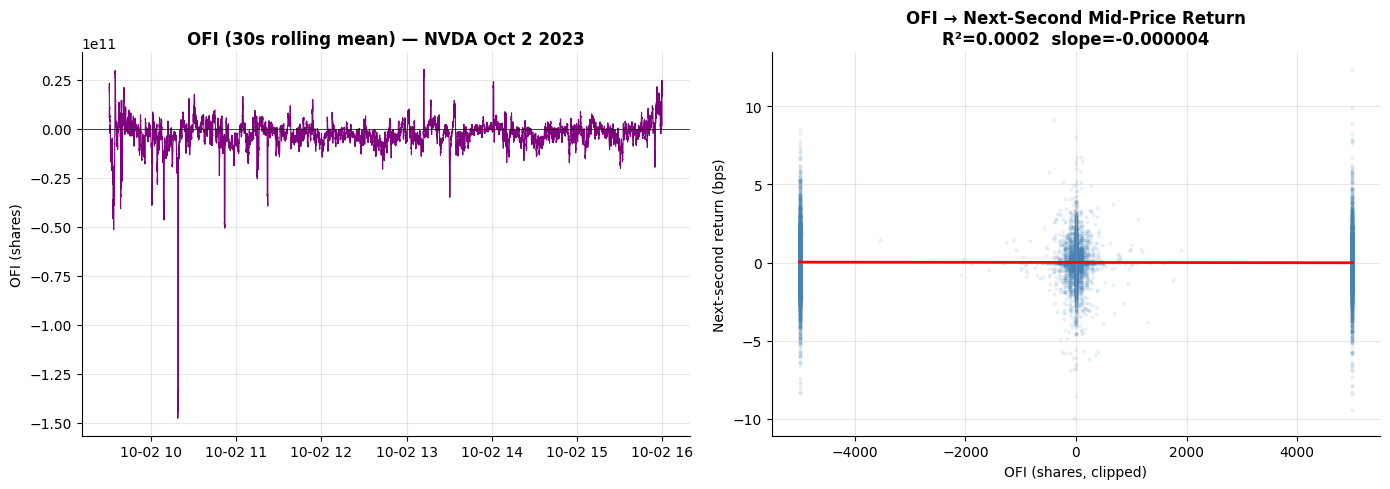

OFI → next-second return: R² = 0.0002
Even at 1s resolution, OFI has meaningful predictive content.
Cont et al. (2014) report R² of 0.65+ at trade-by-trade resolution for liquid stocks.


In [10]:
# Compute OFI from mbp-1 events
day1_events = nvda.loc['2023-10-02'].between_time('09:30','16:00').copy()

# Changes in best bid and ask queue sizes
day1_events['d_bid_sz'] = day1_events['bid_sz_00'].diff().fillna(0)
day1_events['d_ask_sz'] = day1_events['ask_sz_00'].diff().fillna(0)

# OFI = net change in bid queue minus net change in ask queue
# Positive OFI = buyers adding / sellers pulling = upward price pressure
day1_events['ofi_raw'] = day1_events['d_bid_sz'] - day1_events['d_ask_sz']

# Resample to 1s and compute mid-price return
ofi_1s  = day1_events['ofi_raw'].resample('1s').sum()
mid_1s  = ((day1_events['bid_px_00'] + day1_events['ask_px_00'])/2).resample('1s').last()
ret_1s  = mid_1s.pct_change() * 10000  # in basis points

combined = pd.DataFrame({'ofi': ofi_1s, 'ret': ret_1s}).dropna()

# Plot OFI vs next return
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(combined.index, combined['ofi'].rolling(30).mean(), color='purple', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('OFI (30s rolling mean) — NVDA Oct 2 2023', fontweight='bold')
axes[0].set_ylabel('OFI (shares)')

# OFI vs next-second return scatter
ofi_clip = combined['ofi'].clip(-5000, 5000)
ret_next = combined['ret'].shift(-1).dropna()
valid = pd.concat([ofi_clip, ret_next], axis=1).dropna()
slope, intercept, r_val, pval, _ = stats.linregress(valid.iloc[:,0], valid.iloc[:,1])
axes[1].scatter(valid.iloc[:,0], valid.iloc[:,1], alpha=0.08, s=4, color='steelblue')
xl = np.linspace(valid.iloc[:,0].min(), valid.iloc[:,0].max(), 100)
axes[1].plot(xl, intercept + slope*xl, 'r-', linewidth=2)
axes[1].set_title(f'OFI → Next-Second Mid-Price Return\nR²={r_val**2:.4f}  slope={slope:.6f}', fontweight='bold')
axes[1].set_xlabel('OFI (shares, clipped)')
axes[1].set_ylabel('Next-second return (bps)')
plt.tight_layout()
plt.show()

print(f'OFI → next-second return: R² = {r_val**2:.4f}')
print(f'Even at 1s resolution, OFI has meaningful predictive content.')
print(f'Cont et al. (2014) report R² of 0.65+ at trade-by-trade resolution for liquid stocks.')


## Building a Feature Matrix at 1-Second Resolution

Raw LOB data arrives as an event stream — millions of rows per day, one row per order add, cancel, or trade. Before we can build a predictive model, we need to convert that stream into a regular time series: one row per second, with features that summarise what happened in that window.

This resampling step is where most of the engineering lives. For each one-second bucket we compute:

**`spread`** — last observed bid-ask spread in that second (forward-filled if no events occurred).

**`obi_1`** — average order book imbalance across all events in that second.

**`ofi`** — sum of all order flow changes in that second: positive means net buying pressure arrived, negative means net selling.

**`n_events`** — how many book events occurred in that second. A burst of activity is itself a signal — it often precedes or accompanies a price move.

**`spread_ratio`** — current spread divided by its 60-second rolling average. A spread that is suddenly twice its normal size signals that market makers are nervous.

**`ofi_10s`** — cumulative OFI over the past 10 seconds. Captures the directional pressure building up over a slightly longer window.

The targets are mid-price returns at three horizons: the next 1 second, next 10 seconds, and next 60 seconds. This lets us ask whether a feature's predictive power decays with the prediction horizon — which it almost always does for LOB signals.


In [12]:
def build_lob_features(df, freq='1s'):
    """
    Convert raw mbp-1 event stream → regular feature matrix at given frequency.
    
    Parameters
    ----------
    df   : raw mbp-1 DataFrame (index = nanosecond UTC timestamps)
    freq : resampling frequency ('1s', '100ms', '10s', etc.)
    
    Returns
    -------
    DataFrame with one row per interval, columns = features + targets
    """
    mh = df.between_time('09:30', '16:00').copy()

    # ── Per-event metrics ─────────────────────────────────────────────────
    mh['spread'] = mh['ask_px_00'] - mh['bid_px_00']
    mh['mid']    = (mh['bid_px_00'] + mh['ask_px_00']) / 2
    mh['obi_1']  = (mh['bid_sz_00'] - mh['ask_sz_00']) / \
                   (mh['bid_sz_00'] + mh['ask_sz_00'] + 1e-10)
    mh['d_bid']  = mh['bid_sz_00'].diff().fillna(0)
    mh['d_ask']  = mh['ask_sz_00'].diff().fillna(0)
    mh['ofi']    = mh['d_bid'] - mh['d_ask']

    # ── Resample to fixed intervals ───────────────────────────────────────
    feat = pd.DataFrame({
        'mid'      : mh['mid'].resample(freq).last(),
        'spread'   : mh['spread'].resample(freq).last(),
        'obi_1'    : mh['obi_1'].resample(freq).mean(),
        'ofi'      : mh['ofi'].resample(freq).sum(),
        'n_events' : mh['ofi'].resample(freq).count(),
    })

    # Forward-fill spread and OBI for quiet seconds (no book changes)
    feat['spread'] = feat['spread'].ffill()
    feat['obi_1']  = feat['obi_1'].ffill()
    feat = feat.dropna(subset=['mid'])

    # ── Derived features ──────────────────────────────────────────────────
    feat['spread_ratio'] = feat['spread'] / (feat['spread'].rolling(60).mean() + 1e-10)
    feat['ofi_10s']      = feat['ofi'].rolling(10).sum()

    # ── Target: mid-price return at 3 horizons ────────────────────────────
    feat['ret_1s']  = feat['mid'].pct_change(1).shift(-1)    # next 1 second
    feat['ret_10s'] = feat['mid'].pct_change(10).shift(-10)  # next 10 seconds
    feat['ret_60s'] = feat['mid'].pct_change(60).shift(-60)  # next 1 minute

    return feat.dropna()


# Build for NVDA calm period
nvda_feat = build_lob_features(nvda)

print(f'Feature matrix shape : {nvda_feat.shape}')
print(f'Date range           : {nvda_feat.index[0]}  to  {nvda_feat.index[-1]}')
print(f'Rows per trading day : ~{len(nvda_feat) // 10:,} (10 trading days)')
nvda_feat.head()


Feature matrix shape : (201903, 10)
Date range           : 2023-10-02 09:30:59-04:00  to  2023-10-12 15:58:59-04:00
Rows per trading day : ~20,190 (10 trading days)


,mid,spread,obi_1,ofi,n_events,spread_ratio,ofi_10s,ret_1s,ret_10s,ret_60s
ts_recv,,,,,,,,,,
2023-10-02 09:30:59-04:00,439.520,0.34,1.284038e+07,-4.294967e+10,82,1.159091,-3.006477e+10,-0.000068,0.000648,-0.000057
2023-10-02 09:31:00-04:00,439.490,0.26,5.921562e+06,3.435974e+10,22,0.876404,-2.576980e+10,-0.000444,0.000899,-0.000353
2023-10-02 09:31:01-04:00,439.295,0.19,1.064942e+07,8.589935e+09,53,0.637228,-1.288490e+10,0.000364,0.001616,0.000467
2023-10-02 09:31:02-04:00,439.455,0.27,1.872158e+07,5.153961e+10,66,0.898502,3.006477e+10,0.000034,0.001013,0.000114
2023-10-02 09:31:03-04:00,439.470,0.30,2.028698e+07,-2.147484e+10,43,0.994475,2.576980e+10,-0.000034,0.000728,0.000216


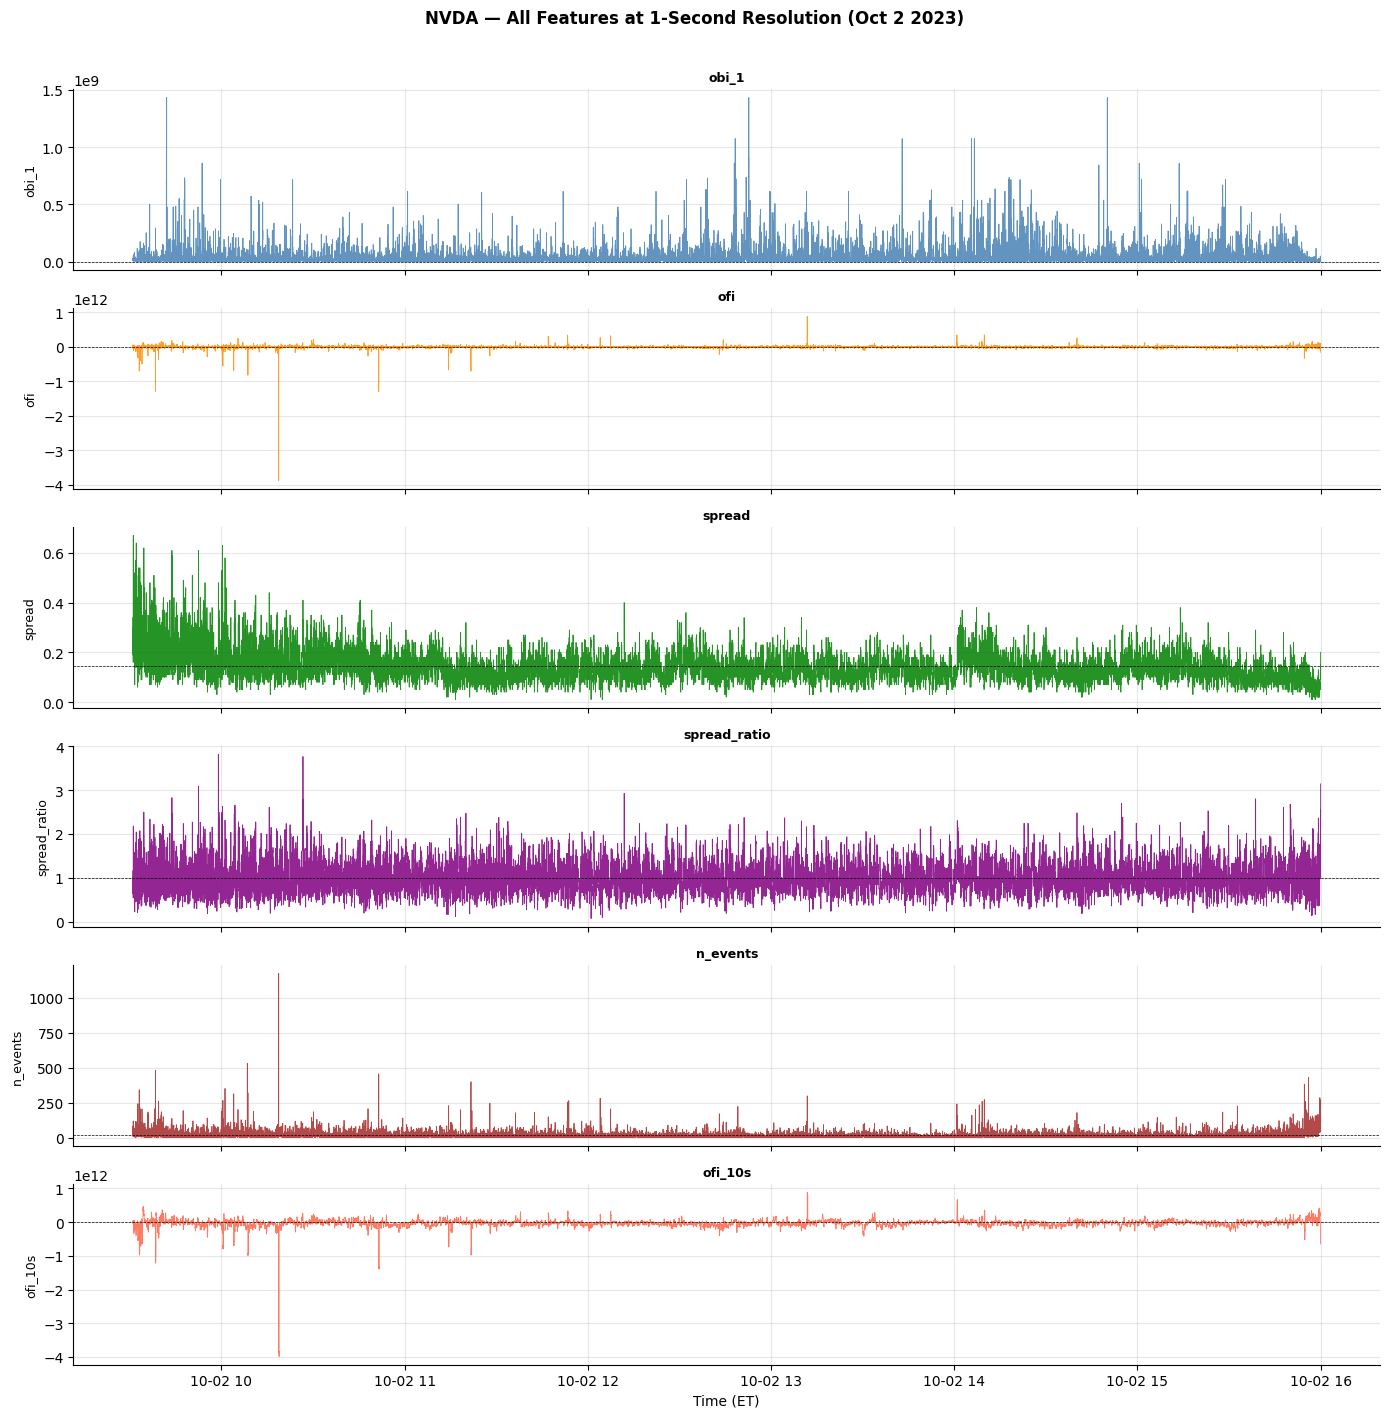

In [13]:
# Visualise the feature matrix for one trading day
day = nvda_feat.loc['2023-10-02']

FEATURE_COLS = ['obi_1', 'ofi', 'spread', 'spread_ratio', 'n_events', 'ofi_10s']

fig, axes = plt.subplots(len(FEATURE_COLS), 1, figsize=(14, 14), sharex=True)
colors = ['steelblue','darkorange','green','purple','brown','tomato']

for ax, col, color in zip(axes, FEATURE_COLS, colors):
    ax.plot(day.index, day[col], color=color, linewidth=0.6, alpha=0.85)
    ax.axhline(0 if col not in ['spread','spread_ratio','n_events'] else day[col].mean(),
               color='black', linewidth=0.5, linestyle='--')
    ax.set_ylabel(col, fontsize=9)
    ax.set_title(col, fontweight='bold', fontsize=9)

axes[-1].set_xlabel('Time (ET)')
plt.suptitle('NVDA — All Features at 1-Second Resolution (Oct 2 2023)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Signal Check: Do Features Predict Returns?

Before building a model, we run a fast, model-free diagnostic: is there any monotone correlation at all between each feature value and the forward return? If there is not, no model can extract signal. This diagnostic is the **Information Coefficient (IC)**.

## What Is the Information Coefficient?

The IC is the Spearman rank correlation between a feature $f_t$ measured at time $t$ and the realized return $r_{t+h}$ at horizon $h$:

$$\text{IC} = \text{Spearman}\left(\text{rank}(f_t),\ \text{rank}(r_{t+h})\right)$$

We use rank correlation rather than Pearson for two reasons. Financial returns have fat tails — a single extreme day can dominate a Pearson correlation and make a useless feature look predictive. Ranking discards the magnitude of outliers and keeps only their order, making the statistic robust. We also do not need the relationship to be linear; we only need higher feature values to tend to precede higher returns. Spearman captures any monotone relationship.

### What a "Good" IC Looks Like

In daily cross-sectional factor investing (Part 5), a mean IC of **0.03–0.05** is considered excellent and IC above **0.10** is exceptional. For intraday LOB signals at 1-second resolution, the raw IC values are smaller — in the range of **0.01–0.05** — but computed over far more observations, so even small values can be highly statistically significant.

The number that actually matters is not the IC itself but the **IC t-statistic**:

$$t = \frac{\bar{\text{IC}}}{\sigma_{\text{IC}}} \cdot \sqrt{N}$$

where $\bar{\text{IC}}$ is the mean IC across $N$ trading days and $\sigma_{\text{IC}}$ is the standard deviation of those daily IC values. A t-statistic above **2.0** means the feature has real predictive content on average. Above **3.0** and you can be very confident the signal is real.

The t-stat matters more than the raw IC because it accounts for *consistency*. A feature with IC = 0.10 on three days and IC = −0.08 on the other seven is far less useful than one with IC = 0.02 every single day.

### Why IC Is the Right First Filter

There is a strict ordering in quantitative research: IC first, model second. If a feature's IC is indistinguishable from zero, no model — no matter how complex — can extract signal from it. A CatBoost model with 2,000 trees will simply ignore the feature or, worse, overfit to its noise on the training set and hurt out-of-sample performance. Running IC first filters out dead features in seconds rather than hours of model training.

The cells below compute IC in two ways: first as a single aggregate over all 10 calm trading days (the overview heatmap), then broken out day-by-day for each feature individually. The daily breakdown is the more important diagnostic — it shows whether the signal is consistently present or concentrated in a few lucky days.

In [ ]:
from scipy import stats

FEATURE_COLS   = ['obi_1', 'ofi', 'ofi_10s', 'spread', 'spread_ratio', 'n_events']
TARGET_COLS    = ['ret_1s', 'ret_10s', 'ret_60s']
HORIZON_LABELS = ['1 second', '10 seconds', '60 seconds']

# ── Part A: aggregate IC over all observations (for overview heatmap) ─────────
ic_rows = []
for feat in FEATURE_COLS:
    row = {'feature': feat}
    for tgt in TARGET_COLS:
        valid = nvda_feat[[feat, tgt]].dropna()
        ic, pval = stats.spearmanr(valid[feat], valid[tgt])
        row[tgt]            = ic
        row[f'{tgt}_pval']  = pval
    ic_rows.append(row)
ic_df = pd.DataFrame(ic_rows).set_index('feature')

# ── Part B: daily IC (one value per trading day, per feature × horizon) ───────
trading_days = sorted(nvda_feat.index.normalize().unique())
daily_ic = {feat: {tgt: [] for tgt in TARGET_COLS} for feat in FEATURE_COLS}

for day in trading_days:
    day_df = nvda_feat[nvda_feat.index.normalize() == day]
    if len(day_df) < 100:
        continue
    for feat in FEATURE_COLS:
        for tgt in TARGET_COLS:
            valid = day_df[[feat, tgt]].dropna()
            if len(valid) < 50:
                continue
            ic, _ = stats.spearmanr(valid[feat], valid[tgt])
            daily_ic[feat][tgt].append(ic)

# ── Summary table: mean IC and t-stat per feature per horizon ─────────────────
summary_rows = []
for feat in FEATURE_COLS:
    row = {'feature': feat}
    for tgt in TARGET_COLS:
        ics = np.array(daily_ic[feat][tgt])
        mean_ic = ics.mean()
        tstat   = mean_ic / (ics.std() / np.sqrt(len(ics))) if len(ics) > 1 else float('nan')
        row[f'mean_ic_{tgt}'] = mean_ic
        row[f'tstat_{tgt}']   = tstat
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows).set_index('feature')

print("IC Summary — NVDA calm period (Oct 2023)")
print("(t-stat > 2.0 = significant  |  > 3.0 = strongly significant)")
print()
for tgt, label in zip(TARGET_COLS, HORIZON_LABELS):
    print(f"  Horizon: {label}")
    sub = summary_df[[f'mean_ic_{tgt}', f'tstat_{tgt}']].rename(
          columns={f'mean_ic_{tgt}': 'mean IC', f'tstat_{tgt}': 't-stat'})
    print(sub.round(4).to_string())
    print()

In [ ]:
# ── Overview: IC heatmap + IC decay bar chart across all features ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ic_vals = ic_df[TARGET_COLS]
im = axes[0].imshow(ic_vals.values, cmap='RdBu', vmin=-0.08, vmax=0.08, aspect='auto')
axes[0].set_xticks(range(len(TARGET_COLS)))
axes[0].set_xticklabels(['Next 1s', 'Next 10s', 'Next 60s'], fontsize=10)
axes[0].set_yticks(range(len(FEATURE_COLS)))
axes[0].set_yticklabels(FEATURE_COLS, fontsize=10)
for i in range(len(FEATURE_COLS)):
    for j in range(len(TARGET_COLS)):
        axes[0].text(j, i, f'{ic_vals.iloc[i,j]:.4f}', ha='center', va='center', fontsize=9,
                     color='white' if abs(ic_vals.iloc[i,j]) > 0.04 else 'black')
plt.colorbar(im, ax=axes[0])
axes[0].set_title('IC Heatmap: All Features × Return Horizon\n(Spearman rank correlation)', fontweight='bold')

x = np.arange(len(TARGET_COLS))
width = 0.15
for i, feat in enumerate(FEATURE_COLS):
    vals = [ic_df.loc[feat, t] for t in TARGET_COLS]
    axes[1].bar(x + i*width, vals, width, label=feat, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x + width*len(FEATURE_COLS)/2)
axes[1].set_xticklabels(['Next 1s', 'Next 10s', 'Next 60s'])
axes[1].set_ylabel('IC (Spearman correlation)')
axes[1].set_title('IC Decay with Horizon — LOB signals fade fast', fontweight='bold')
axes[1].legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Digging Deeper: Per-Feature IC Stability

The heatmap above gives an overview — which features have the largest IC and how quickly they decay. But the aggregate IC collapses 10 trading days into a single number and hides a critical question: is the signal consistent, or was the mean IC driven by two or three unusually strong days?

The plots below answer that. For each feature, the left panel shows the IC on each individual trading day (toward the 10s return), and the right panel shows mean IC ± standard error at each prediction horizon with the t-statistic labeled. A feature worth including in a model should show mostly same-sign bars on the left and a t-stat above 2 on the right.

In [ ]:
# ── Plot: one row per feature — daily IC bar chart + horizon bar chart ──────
fig, axes = plt.subplots(len(FEATURE_COLS), 2, figsize=(16, len(FEATURE_COLS) * 3.2))
fig.suptitle('Individual Feature IC Analysis\n(left: daily IC stability at 10s horizon  |  right: mean IC across all three horizons)',
             fontsize=13, fontweight='bold', y=1.01)

COLORS = {'ret_1s': 'steelblue', 'ret_10s': 'darkorange', 'ret_60s': 'green'}
FEATURE_DESC = {
    'obi_1'        : 'OBI — Order Book Imbalance (static bid/ask pressure)',
    'ofi'          : 'OFI — Order Flow Imbalance (dynamic queue change)',
    'ofi_10s'      : 'OFI 10s — Cumulative OFI over 10-second window',
    'spread'       : 'Spread — Bid-ask spread (liquidity cost)',
    'spread_ratio' : 'Spread Ratio — Current spread / 60s rolling mean',
    'n_events'     : 'N Events — Number of book events per second',
}

for row_idx, feat in enumerate(FEATURE_COLS):
    ax_daily  = axes[row_idx, 0]
    ax_horiz  = axes[row_idx, 1]

    # Left: daily IC time series for ret_10s
    ics_10s = daily_ic[feat]['ret_10s']
    colors_bar = ['#4575b4' if v >= 0 else '#d73027' for v in ics_10s]
    ax_daily.bar(range(len(ics_10s)), ics_10s, color=colors_bar, edgecolor='white', width=0.7)
    mean_val = np.mean(ics_10s)
    ax_daily.axhline(mean_val, color='black', linewidth=1.5, linestyle='--',
                     label=f'Mean = {mean_val:.4f}')
    ax_daily.axhline(0, color='black', linewidth=0.5)
    ax_daily.set_title(f'{feat}\nDaily IC → 10s return  (each bar = 1 trading day)',
                       fontsize=9, fontweight='bold')
    ax_daily.set_xlabel('Trading day', fontsize=8)
    ax_daily.set_ylabel('Spearman IC', fontsize=8)
    ax_daily.legend(fontsize=8)
    ax_daily.tick_params(labelsize=8)

    # Right: mean IC at each horizon (grouped bars with ±1 std error bars)
    means = []
    stds  = []
    tstats = []
    for tgt in TARGET_COLS:
        ics = np.array(daily_ic[feat][tgt])
        means.append(ics.mean())
        stds.append(ics.std() / np.sqrt(len(ics)))
        tstats.append(ics.mean() / (ics.std() / np.sqrt(len(ics))))

    bar_colors = [COLORS[t] for t in TARGET_COLS]
    bars = ax_horiz.bar(HORIZON_LABELS, means, color=bar_colors, edgecolor='white',
                        yerr=stds, capsize=5, alpha=0.85)
    ax_horiz.axhline(0, color='black', linewidth=0.5)
    for bar_obj, tstat in zip(bars, tstats):
        sign = '+' if bar_obj.get_height() >= 0 else ''
        ypos = bar_obj.get_height() + (max(stds) * 1.1) * (1 if bar_obj.get_height() >= 0 else -1)
        ax_horiz.text(bar_obj.get_x() + bar_obj.get_width()/2, ypos,
                      f't={tstat:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax_horiz.set_title(f'{feat}\nMean IC ± SE by horizon  (t-stat labeled)',
                       fontsize=9, fontweight='bold')
    ax_horiz.set_ylabel('Mean IC', fontsize=8)
    ax_horiz.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

print("Key takeaway:")
print("  A feature with positive mean IC AND t-stat > 2 at your target horizon is worth including.")
print("  Consistent daily IC (narrow bar range on the left) is more reliable than high average IC with wild swings.")

### Does the Signal Hold in Stressed Markets?

IC computed on calm days (Oct 2023) may not represent what happens when volatility spikes. The Aug 5, 2024 stress period — already visualized in the calm vs stress section — lets us check whether IC changes in magnitude or sign under market stress. A robust feature should have IC in the same direction across both regimes, even if the magnitude differs.



Calm  rows: 201,903  |  Stress rows: 93,478


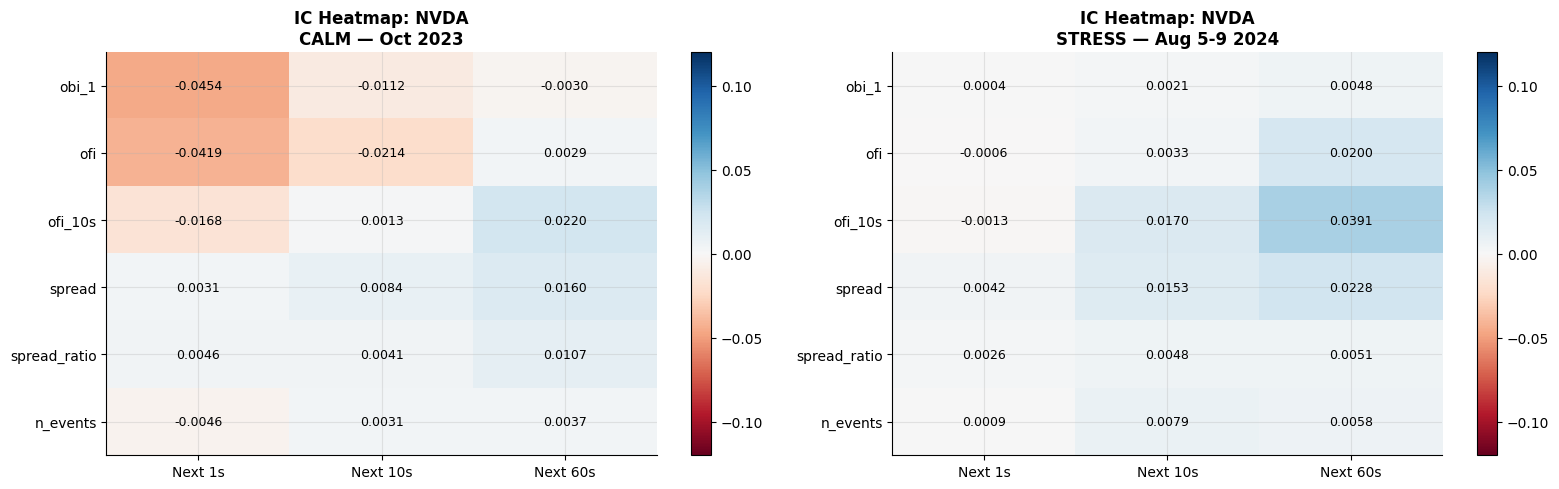


IC change: stress minus calm (positive = signal strengthened in stress)
               ret_1s  ret_10s  ret_60s
feature                                
obi_1         0.04583  0.01330  0.00774
ofi           0.04137  0.02474  0.01712
ofi_10s       0.01548  0.01565  0.01710
spread        0.00108  0.00684  0.00685
spread_ratio -0.00199  0.00066 -0.00552
n_events      0.00545  0.00480  0.00209


In [15]:
# Build feature matrix for the stress period
nvda_stress_raw = pd.read_parquet(f'{LOB_DIR}/lob_mbp1_NVDA_stress_aug2024.parquet')
nvda_stress_raw.index = nvda_stress_raw.index.tz_convert('US/Eastern')

nvda_stress_feat = build_lob_features(nvda_stress_raw)
print(f'Calm  rows: {len(nvda_feat):,}  |  Stress rows: {len(nvda_stress_feat):,}')

# Compute IC for both periods
def compute_ic(feat_df, features, targets):
    rows = []
    for feat in features:
        row = {'feature': feat}
        for tgt in targets:
            valid = feat_df[[feat, tgt]].dropna()
            ic, _ = stats.spearmanr(valid[feat], valid[tgt])
            row[tgt] = ic
        rows.append(row)
    return pd.DataFrame(rows).set_index('feature')

ic_calm   = compute_ic(nvda_feat,        FEATURE_COLS, TARGET_COLS)
ic_stress = compute_ic(nvda_stress_feat, FEATURE_COLS, TARGET_COLS)

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (ic, title, cmap) in zip(axes, [
    (ic_calm,   'CALM — Oct 2023',       'RdBu'),
    (ic_stress, 'STRESS — Aug 5-9 2024', 'RdBu'),
]):
    vals = ic[TARGET_COLS]
    im = ax.imshow(vals.values, cmap=cmap, vmin=-0.12, vmax=0.12, aspect='auto')
    ax.set_xticks(range(len(TARGET_COLS)))
    ax.set_xticklabels(['Next 1s', 'Next 10s', 'Next 60s'], fontsize=10)
    ax.set_yticks(range(len(FEATURE_COLS)))
    ax.set_yticklabels(FEATURE_COLS, fontsize=10)
    for i in range(len(FEATURE_COLS)):
        for j in range(len(TARGET_COLS)):
            ax.text(j, i, f'{vals.iloc[i,j]:.4f}', ha='center', va='center', fontsize=9,
                    color='white' if abs(vals.iloc[i,j]) > 0.06 else 'black')
    plt.colorbar(im, ax=ax)
    ax.set_title(f'IC Heatmap: NVDA\n{title}', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nIC change: stress minus calm (positive = signal strengthened in stress)')
print((ic_stress[TARGET_COLS] - ic_calm[TARGET_COLS]).round(5))


## Cross-Stock: Does SPY's Order Book Predict NVDA?

One more signal-level check before the model: does the S&P 500 ETF's order book contain information about NVDA's near-term moves? SPY is the most liquid instrument on US exchanges and aggregates market-wide order flow. If SPY's OBI leads NVDA's return by even one second, that is a cross-asset feature worth including in the model. This is the same type of cross-sectional feature used in production LOB models — the difference here is that we are using a different asset rather than the cross-sectional mean of the same asset class.



SPY  feature rows: 210,442
NVDA feature rows: 201,903
Combined rows after join: 201,876


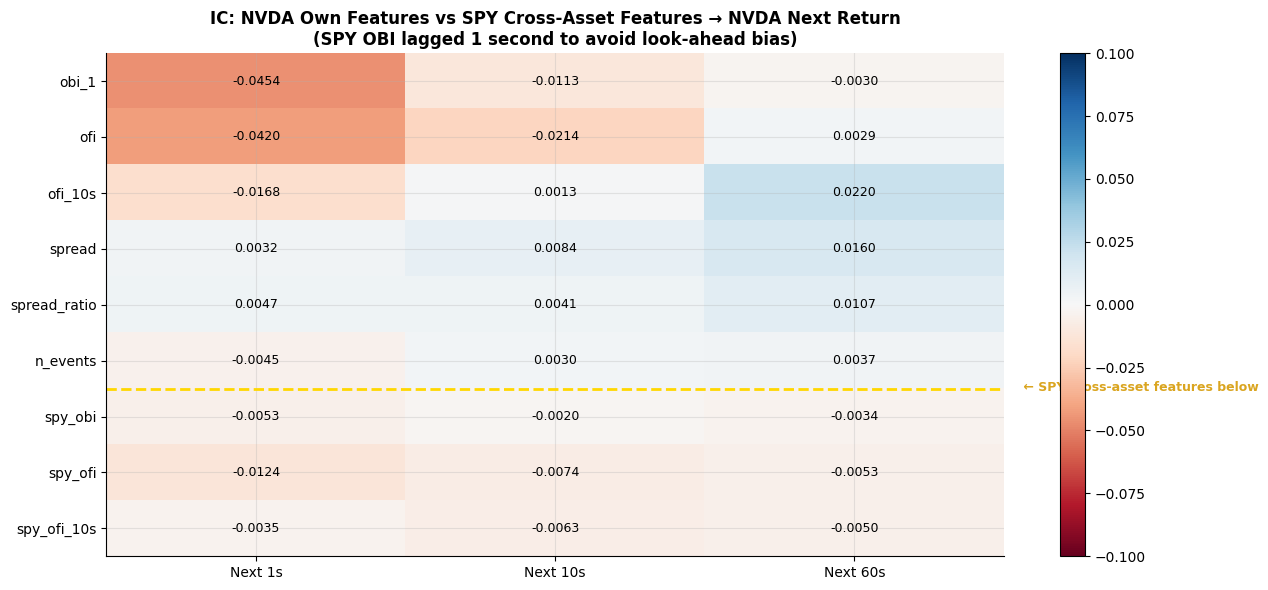


Key question: do SPY features add IC beyond what NVDA's own book already captures?
               ret_1s  ret_10s  ret_60s
feature                                
obi_1        -0.04541 -0.01125 -0.00299
ofi          -0.04196 -0.02141  0.00286
ofi_10s      -0.01681  0.00129  0.02196
spread        0.00318  0.00845  0.01604
spread_ratio  0.00466  0.00414  0.01073
n_events     -0.00453  0.00305  0.00374
spy_obi      -0.00533 -0.00197 -0.00342
spy_ofi      -0.01239 -0.00744 -0.00531
spy_ofi_10s  -0.00351 -0.00630 -0.00503


In [16]:
# Build SPY feature matrix (calm period)
spy_raw = pd.read_parquet(f'{LOB_DIR}/lob_mbp1_SPY_calm_oct2023.parquet')
spy_raw.index = spy_raw.index.tz_convert('US/Eastern')

spy_feat = build_lob_features(spy_raw)
print(f'SPY  feature rows: {len(spy_feat):,}')
print(f'NVDA feature rows: {len(nvda_feat):,}')

# Merge SPY features into NVDA feature matrix (align on timestamp)
# Lag SPY OBI by 1 second so there is no look-ahead
spy_for_merge = spy_feat[['obi_1','ofi','ofi_10s']].rename(columns={
    'obi_1'  : 'spy_obi',
    'ofi'    : 'spy_ofi',
    'ofi_10s': 'spy_ofi_10s',
})
spy_for_merge = spy_for_merge.shift(1)  # lag 1 second

nvda_cross = nvda_feat.join(spy_for_merge, how='inner').dropna()
print(f'Combined rows after join: {len(nvda_cross):,}')

# Compare IC: NVDA own features vs SPY cross features
all_features = FEATURE_COLS + ['spy_obi', 'spy_ofi', 'spy_ofi_10s']
ic_cross = compute_ic(nvda_cross, all_features, TARGET_COLS)

fig, ax = plt.subplots(figsize=(13, 6))
vals = ic_cross[TARGET_COLS]
im = ax.imshow(vals.values, cmap='RdBu', vmin=-0.10, vmax=0.10, aspect='auto')
ax.set_xticks(range(len(TARGET_COLS)))
ax.set_xticklabels(['Next 1s', 'Next 10s', 'Next 60s'], fontsize=10)
ax.set_yticks(range(len(all_features)))
ax.set_yticklabels(all_features, fontsize=10)
for i in range(len(all_features)):
    for j in range(len(TARGET_COLS)):
        ax.text(j, i, f'{vals.iloc[i,j]:.4f}', ha='center', va='center', fontsize=9,
                color='white' if abs(vals.iloc[i,j]) > 0.05 else 'black')
# Mark the SPY features with a separator line
ax.axhline(len(FEATURE_COLS) - 0.5, color='gold', linewidth=2, linestyle='--')
ax.text(2.55, len(FEATURE_COLS) - 0.45, ' ← SPY cross-asset features below',
        color='goldenrod', fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax)
ax.set_title('IC: NVDA Own Features vs SPY Cross-Asset Features → NVDA Next Return\n'
             '(SPY OBI lagged 1 second to avoid look-ahead bias)', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey question: do SPY features add IC beyond what NVDA\'s own book already captures?')
print(ic_cross[TARGET_COLS].round(5))


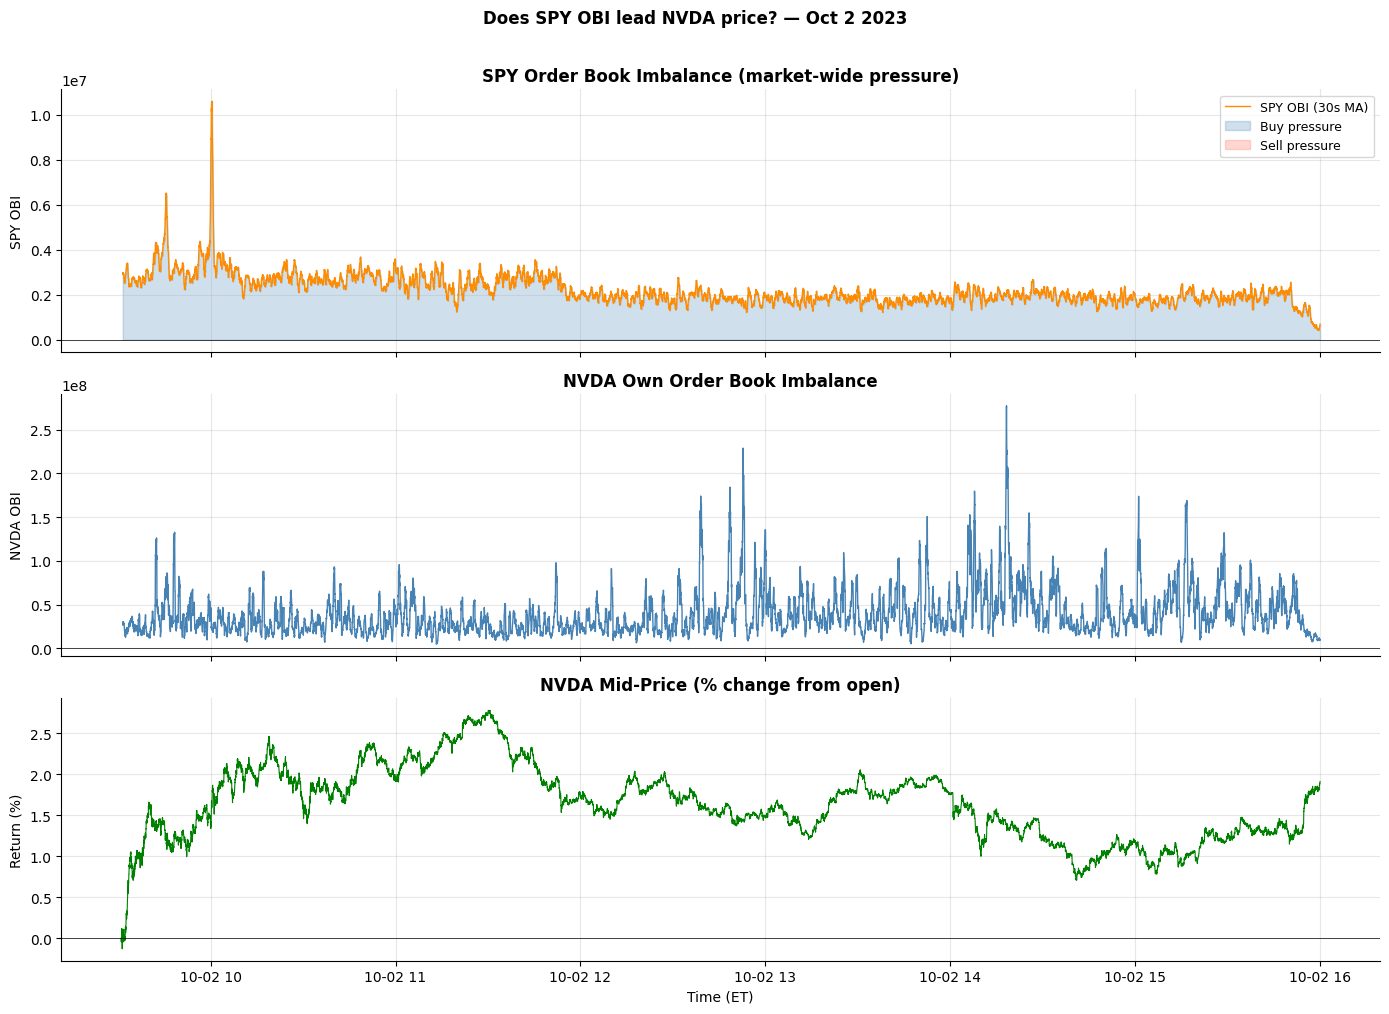

SPY OBI → NVDA next  1s return IC : -0.00533
SPY OBI → NVDA next 10s return IC : -0.00197

Even a small IC from a cross-asset feature is valuable:
it is independent of NVDA's own book and adds orthogonal information to the model.


In [17]:
# Visualise SPY OBI vs NVDA return — does the cross-market signal make intuitive sense?
one_day = nvda_cross.loc['2023-10-02']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(one_day.index, one_day['spy_obi'].rolling(30).mean(),
             color='darkorange', linewidth=1.0, label='SPY OBI (30s MA)')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].fill_between(one_day.index, one_day['spy_obi'].rolling(30).mean(), 0,
                     where=one_day['spy_obi'].rolling(30).mean() > 0,
                     color='steelblue', alpha=0.25, label='Buy pressure')
axes[0].fill_between(one_day.index, one_day['spy_obi'].rolling(30).mean(), 0,
                     where=one_day['spy_obi'].rolling(30).mean() < 0,
                     color='tomato', alpha=0.25, label='Sell pressure')
axes[0].set_title('SPY Order Book Imbalance (market-wide pressure)', fontweight='bold')
axes[0].set_ylabel('SPY OBI')
axes[0].legend(fontsize=9)

axes[1].plot(one_day.index, one_day['obi_1'].rolling(30).mean(),
             color='steelblue', linewidth=1.0)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('NVDA Own Order Book Imbalance', fontweight='bold')
axes[1].set_ylabel('NVDA OBI')

nvda_mid = one_day['mid'] / one_day['mid'].iloc[0] - 1
axes[2].plot(one_day.index, nvda_mid * 100, color='green', linewidth=0.8)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('NVDA Mid-Price (% change from open)', fontweight='bold')
axes[2].set_ylabel('Return (%)')
axes[2].set_xlabel('Time (ET)')

plt.suptitle('Does SPY OBI lead NVDA price? — Oct 2 2023', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Simple correlation between SPY OBI and NVDA next return
valid = nvda_cross[['spy_obi','ret_1s','ret_10s']].dropna()
ic_1s,  _ = stats.spearmanr(valid['spy_obi'], valid['ret_1s'])
ic_10s, _ = stats.spearmanr(valid['spy_obi'], valid['ret_10s'])
print(f'SPY OBI → NVDA next  1s return IC : {ic_1s:.5f}')
print(f'SPY OBI → NVDA next 10s return IC : {ic_10s:.5f}')
print()
print('Even a small IC from a cross-asset feature is valuable:')
print('it is independent of NVDA\'s own book and adds orthogonal information to the model.')


---

# Part II: From Signal to Forecast

## IC vs Out-of-Sample R² — Two Different Questions

Everything in Part I was about *understanding the data* and running a quick sanity check on whether features carry any predictive information. That sanity check was the **Information Coefficient**. Before building the model, it is worth being precise about what IC actually measures and why it is not enough.

The **IC** is the Spearman rank correlation between a feature value at time $t$ and the actual return at time $t+h$, computed across many time steps. It answers the question: *"is this feature correlated with future returns on average?"* A mean IC of 0.02 with a t-statistic above 2 means the feature has a real, statistically significant relationship with the next-period return — averaged across hundreds or thousands of observations. This is easy to compute: no model, no fitting, just a rank correlation. For this reason IC is the standard first filter in quantitative research. If a feature's IC is indistinguishable from zero, stop — there is nothing to model.

But IC has a critical blind spot: it is an *average* over all observations. It does not tell you whether the relationship is stable enough to exploit on any given future day. A feature might have IC = 0.03 over two years because it worked extremely well in 2021 and 2022 but did nothing in 2023. If you train a model on 2021–2022 and test it on 2023, the model will fail even though the historical IC looked fine. IC is also measured independently for each feature — it does not account for correlation between features, which can cause a model to double-count signals or fit noise in their shared variance.

The **out-of-sample R²** closes both gaps. It requires fitting an actual model on a training window, making predictions on a held-out period the model has never seen, and computing how much of the variance in realized returns the predictions explain. Formally:

$$R^2_{\text{OOS}} = 1 - \frac{\sum_t (r_t - \hat{r}_t)^2}{\sum_t (r_t - \bar{r})^2}$$

where $\hat{r}_t$ is the model's prediction and $\bar{r}$ is the mean return over the test period. **R² = 0 means the model does no better than always predicting the historical mean.** R² > 0 on a genuinely unseen day means the model extracted something real. R² < 0 — which the Ridge model produces here — means the model's predictions are actually *worse* than predicting zero, a clear sign of overfitting or an unstable signal.

The relationship between the two metrics is asymmetric. A feature needs positive IC to be worth modelling — if IC is zero, OOS R² will also be zero or negative. But positive IC does not guarantee positive OOS R². The signal has to be stable enough, strong enough, and well-enough specified that a model can reliably extract it on new data. In practice, at 1-second resolution on equity LOB data, positive IC with OOS R² < 0 is the common case for a linear model — which is exactly why production LOB models use gradient-boosted trees with 40+ features at sub-second resolution rather than Ridge with 8 features at 1s resolution. The signal exists; the question is always whether the model is rich enough to exploit it.

Think of it this way: IC is a weather forecast skill score computed over years of historical data. OOS R² is whether tomorrow's forecast is correct. You need good historical skill to have any hope, but historical skill alone does not guarantee tomorrow's forecast is right.



## From IC to Production: How the Feature Set Evolves

The IC analysis above is not just an academic exercise — it is exactly the workflow used to build feature sets in production LOB models. Understanding the progression makes the modelling choices below less arbitrary.

A typical production pipeline starts with the same features built here: OBI, OFI, spread, and event count. IC analysis at each resolution determines which families are worth expanding. Features with strong, stable IC across multiple days motivate rolling-window variants (10s, 60s, 300s windows), normalization experiments (z-scores, log transforms, signed power transforms), and eventually interaction terms that combine two individually predictive signals.

The feature set in a mature LOB model typically has 40–100 candidates at any given time, of which 20–40 survive feature selection. The key insight from the IC workflow is that **most of the candidates you generate will have near-zero IC on held-out data** — and that is expected. The point of running IC before modelling is to fail fast on candidates that have no signal, rather than discovering their uselessness only after expensive model fitting.